# M2A3 - Classificadores Supervisionados

> **Resumo:** Agora que sabemos extrair características de imagens, como usar essas informações pra **classificar** imagens automaticamente? Aqui conhecemos 3 classificadores clássicos: KNN, SVM e Árvores de Decisão.

> 📝 **Importante:** Esses modelos NÃO são redes neurais! São algoritmos de ML clássico que funcionam muito bem pra muitos problemas.

**Estrutura do notebook:**

- Conceitos teóricos (KNN, SVM, Árvore)
- Prática com scikit-learn usando dataset de dígitos
- Comparação dos 3 classificadores
- ✅ Atividades Complementares

## Conceitos

### KNN (K-Nearest Neighbors)
- Olha os K vizinhos mais próximos de um novo dado e faz votação
- Simples e intuitivo: "diz-me com quem andas..."
- Distância geralmente euclidiana

### SVM (Support Vector Machines)
- Cria fronteiras (hiperplanos) que separam as classes
- Maximiza a margem entre as classes
- Funciona bem em espaços de alta dimensão

### Árvores de Decisão
- Como um fluxograma de perguntas sim/não
- Fácil de interpretar (dá pra entender POR QUE o modelo decidiu)
- Pode sofrer overfitting se ficar muito profunda

## Prática — Classificando Dígitos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Total de imagens: 1797
Shape de cada imagem: (8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


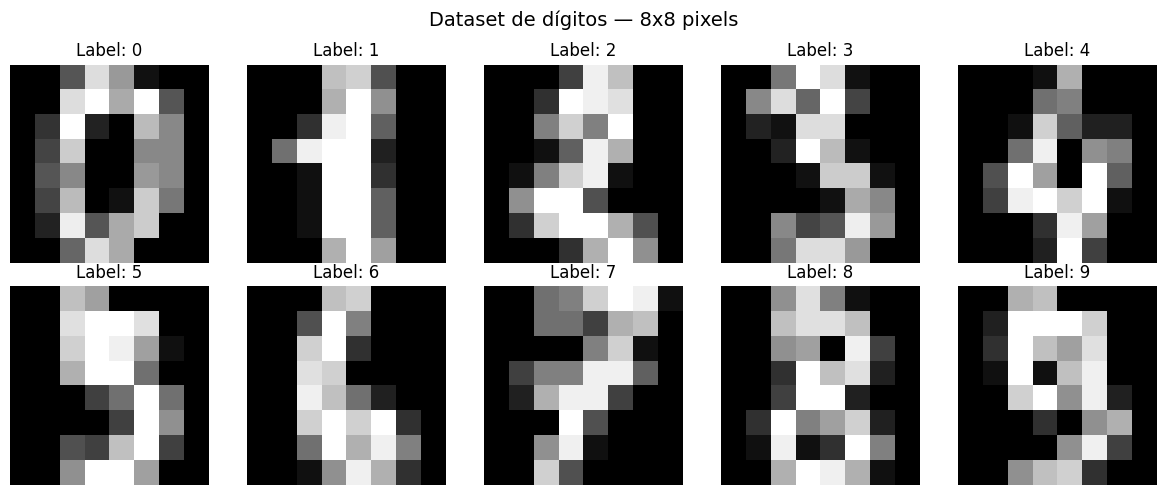

In [2]:
# Carregar o dataset de dígitos do scikit-learn (mini-MNIST)
digits = datasets.load_digits()

print(f"Total de imagens: {len(digits.images)}")
print(f"Shape de cada imagem: {digits.images[0].shape}")
print(f"Classes: {digits.target_names}")

# Visualizar alguns exemplos
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, label in zip(axes.flat, digits.images[:10], digits.target[:10]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("Dataset de dígitos — 8x8 pixels", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
# Preparar dados: achatar imagens 8x8 → vetor de 64 features
X = digits.data  # já vem achatado
y = digits.target

# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

Treino: 1437 | Teste: 360


### Treinando os 3 classificadores

In [4]:
# KNN com K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

# SVM
svm = SVC(kernel='rbf', gamma='scale')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

# Árvore de Decisão
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

print(f"KNN (K=5):           {acc_knn*100:.1f}%")
print(f"SVM (RBF):           {acc_svm*100:.1f}%")
print(f"Árvore de Decisão:   {acc_tree*100:.1f}%")

KNN (K=5):           98.6%
SVM (RBF):           98.6%
Árvore de Decisão:   84.2%


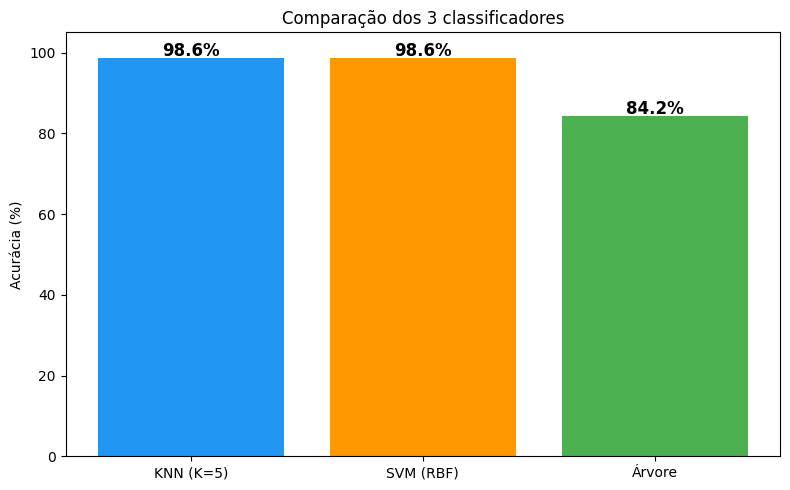

In [5]:
# Comparação visual
models = ['KNN (K=5)', 'SVM (RBF)', 'Árvore']
accs = [acc_knn, acc_svm, acc_tree]
colors = ['#2196F3', '#FF9800', '#4CAF50']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, [a * 100 for a in accs], color=colors)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.ylabel("Acurácia (%)")
plt.title("Comparação dos 3 classificadores")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

> 📝 **Observação:** O SVM geralmente ganha em datasets de imagens (alta dimensionalidade). A Árvore de Decisão tende a ter performance pior por causa de overfitting.

## ✅ Atividades Complementares

### Variando o K do KNN

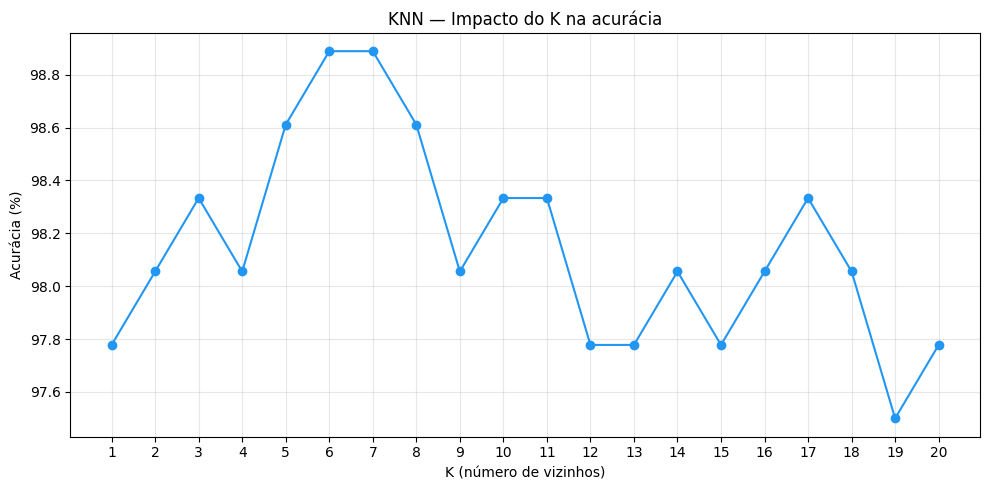

Melhor K: 6 com acurácia 98.9%
Detalhamento da acurácia por K no KNN:
  - K = 01: 97.78%
  - K = 02: 98.06%
  - K = 03: 98.33%
  - K = 04: 98.06%
  - K = 05: 98.61%
  - K = 06: 98.89%
  - K = 07: 98.89%
  - K = 08: 98.61%
  - K = 09: 98.06%
  - K = 10: 98.33%
  - K = 11: 98.33%
  - K = 12: 97.78%
  - K = 13: 97.78%
  - K = 14: 98.06%
  - K = 15: 97.78%
  - K = 16: 98.06%
  - K = 17: 98.33%
  - K = 18: 98.06%
  - K = 19: 97.50%
  - K = 20: 97.78%


In [6]:
ks = range(1, 21)
accs_k = []
for k in ks:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    accs_k.append(accuracy_score(y_test, knn_k.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(ks, [a * 100 for a in accs_k], 'o-', color='#2196F3')
plt.xlabel("K (número de vizinhos)")
plt.ylabel("Acurácia (%)")
plt.title("KNN — Impacto do K na acurácia")
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = ks[np.argmax(accs_k)]
print(f"Melhor K: {best_k} com acurácia {max(accs_k)*100:.1f}%")

print("Detalhamento da acurácia por K no KNN:")
for k, acc in zip(ks, accs_k):
    print(f"  - K = {k:02d}: {acc*100:.2f}%")

### Visualizando predições erradas

Total de erros do SVM: 5
Detalhamento das imagens classificadas incorretamente pelo SVM:
  - Índice no conjunto de teste 118: Real 8 | Predito 9
  - Índice no conjunto de teste 133: Real 7 | Predito 9
  - Índice no conjunto de teste 159: Real 9 | Predito 7
  - Índice no conjunto de teste 249: Real 9 | Predito 5
  - Índice no conjunto de teste 339: Real 5 | Predito 6


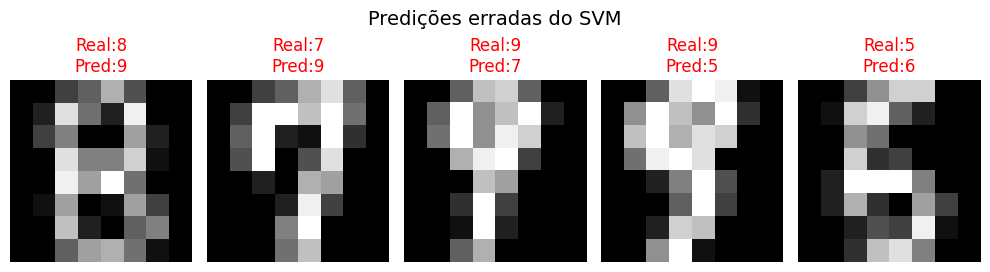

In [7]:
# Usando o SVM (melhor modelo)
errors = np.where(y_pred_svm != y_test)[0]
print(f"Total de erros do SVM: {len(errors)}")

if len(errors) > 0:
    print("Detalhamento das imagens classificadas incorretamente pelo SVM:")
    for idx in errors:
        print(f"  - Índice no conjunto de teste {idx:03d}: Real {y_test[idx]} | Predito {y_pred_svm[idx]}")


if len(errors) > 0:
    n_show = min(10, len(errors))
    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, errors[:n_show]):
        ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
        ax.set_title(f"Real:{y_test[idx]}\nPred:{y_pred_svm[idx]}", color='red')
        ax.axis("off")
    plt.suptitle("Predições erradas do SVM", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("O SVM acertou tudo! 🎉")

> 📝 **Análise dos erros do SVM:** O SVM errou apenas 5 vezes de 360 amostras (acurácia espetacular de ~98.6%!). Ao olhar os erros específicos (8 confundido com 9, 7 com 9, 9 com 7, 9 com 5 e 5 com 6), vemos que são dígitos muito parecidos na forma escrita manual, principalmente em resolução 8x8 onde as curvas e traços finos se perdem.